# Jupyter Notebook

- Author: [Venkat Teja Nallamothu](https://github.com/vnallam09/)
- Repository: [pro-analytics-02](https://github.com/vnallam09/pro-analytics-02)

## Section 1. Basic EDA on Iris dataset


In [1]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import seaborn as sns  # built in chart styles, built on matplotlib

## Section 3. Data Description

This analysis uses the built-in `iris` dataset from the Seaborn package.  
It is the famous iris flower dataset originally collected by Edgar Anderson and made famous by Ronald Fisher's use of it in his 1936 paper "The use of multiple measurements in taxonomic problems". The data describe physical measurements for iris flowers from three species.

The dataset includes **150 rows** (individual iris flowers) and **5 columns** (attributes):

| Column | Type | Description |
|---------|------|-------------|
| `sepal_length` | numeric (float) | Length of the sepal in centimeters. |
| `sepal_width` | numeric (float) | Width of the sepal in centimeters. |
| `bill_depth_mm` | numeric (float) | Length of the petal in centimeters. |
| `petal_width` | numeric (float) | Width of the petal in centimeters. |
| `species` | categorical | Iris species: *setosa*, *versicolor*, or *virginica*. |

### Notes
- This is a **clean dataset** with no missing values, making it ideal for exploratory data analysis and machine learning.  
- The dataset contains both **numeric** and **categorical** features, perfect for practicing various visualization techniques and statistical analysis methods.
- Each species has exactly **50 samples**, making it a balanced dataset.

In [2]:
# Load the iris dataset
df_iris = sns.load_dataset("iris")

# Display basic information about the dataset
print("Iris Dataset Shape:", df_iris.shape)
print("\nFirst 5 rows:")
print(df_iris.head())
print("\nDataset Info:")
print(df_iris.info())
print("\nBasic Statistics:")
print(df_iris.describe())

Iris Dataset Shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Basic Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000

## Section 4. Analysis and Visualization

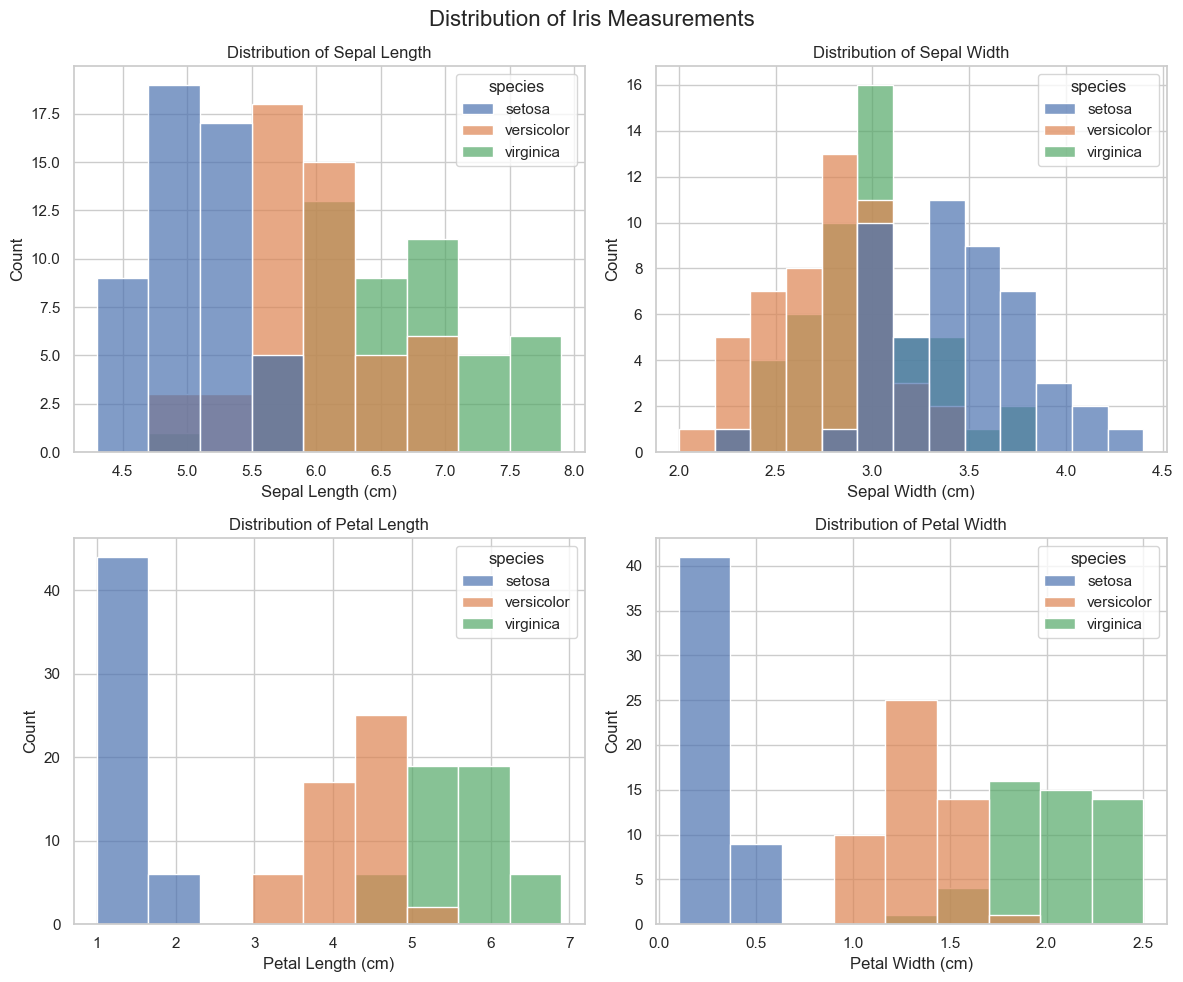

In [3]:
# Set Seaborn theme for consistent styling
sns.set_theme(style="whitegrid")

# 4.1 Distribution Analysis - Histogram of all numeric features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Iris Measurements', fontsize=16)

# Plot histograms for each numeric feature
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    sns.histplot(data=df_iris, x=col, hue='species', alpha=0.7, ax=ax)
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}')
    ax.set_xlabel(f'{col.replace("_", " ").title()} (cm)')

plt.tight_layout()
plt.show()

### 4.2 Species Comparison Analysis

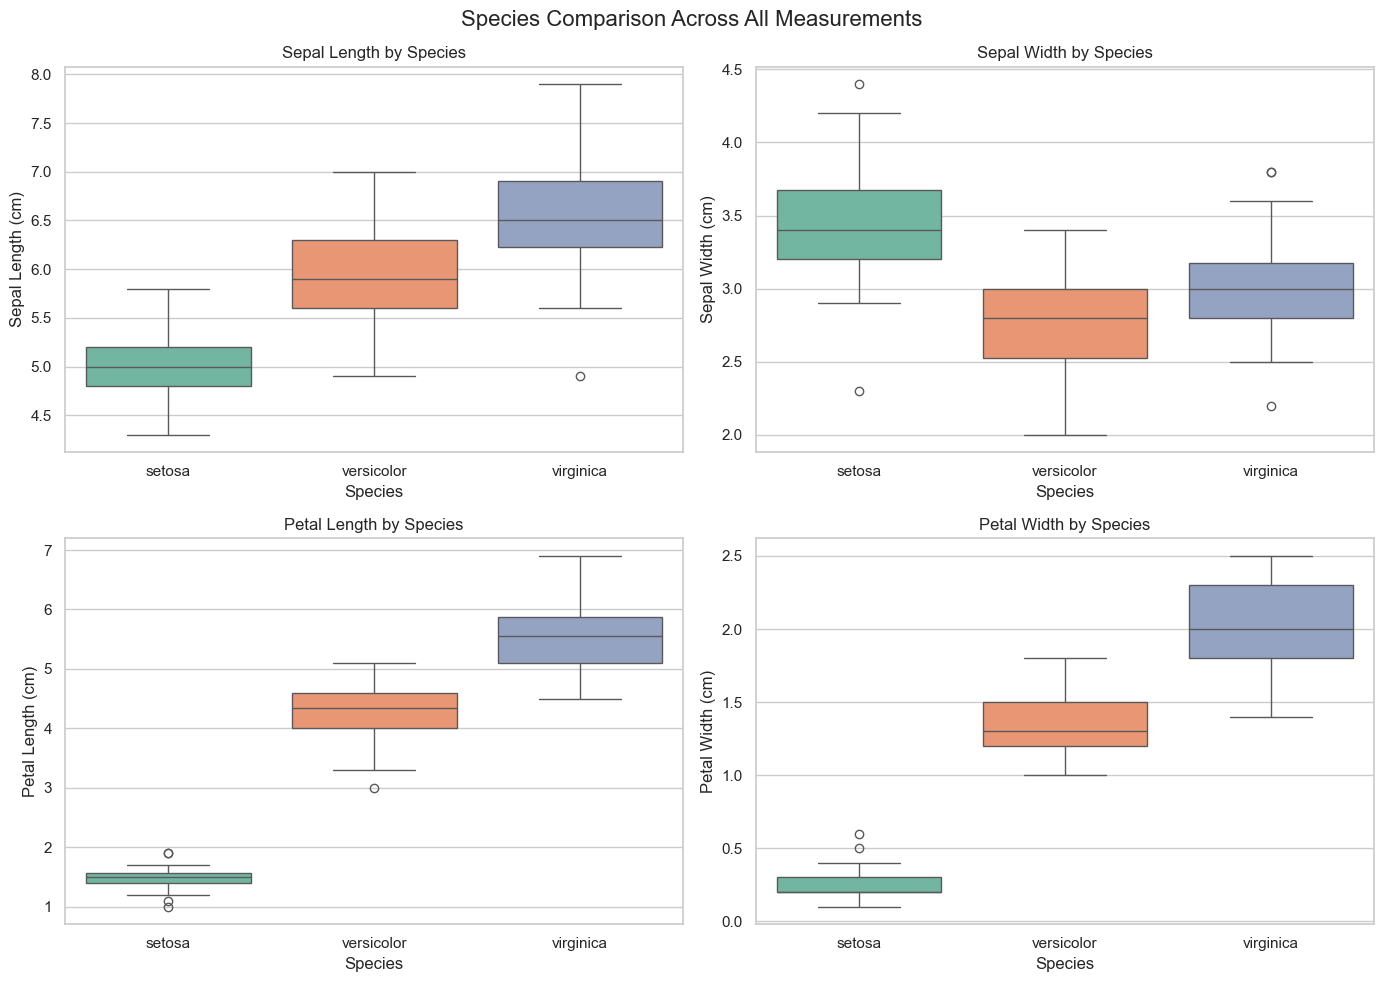

In [4]:
# 4.2 Box plots to compare species across all measurements
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Species Comparison Across All Measurements', fontsize=16)

for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    sns.boxplot(data=df_iris, x='species', y=col, hue='species', ax=ax, palette='Set2', legend=False)
    ax.set_title(f'{col.replace("_", " ").title()} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(f'{col.replace("_", " ").title()} (cm)')

plt.tight_layout()
plt.show()

### 4.3 Correlation Analysis

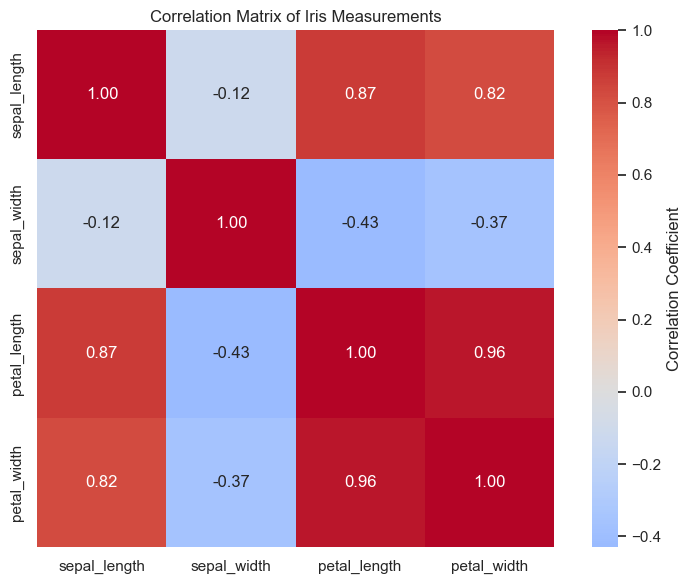

Key Correlation Insights:
sepal_length vs sepal_width: -0.118

sepal_length vs petal_length: 0.872
  → Strong correlation detected!

sepal_length vs petal_width: 0.818
  → Strong correlation detected!

sepal_width vs petal_length: -0.428

sepal_width vs petal_width: -0.366

petal_length vs petal_width: 0.963
  → Strong correlation detected!



In [5]:
# 4.3 Correlation matrix heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df_iris[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Iris Measurements')
plt.tight_layout()
plt.show()

# Print correlation insights
print("Key Correlation Insights:")
print("=" * 40)
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr_val = correlation_matrix.iloc[i, j]
        print(f"{numeric_cols[i]} vs {numeric_cols[j]}: {corr_val:.3f}")
        if abs(corr_val) > 0.8:
            print(f"  → Strong correlation detected!")
        elif abs(corr_val) > 0.6:
            print(f"  → Moderate correlation detected!")
        print()

### 4.4 Pairwise Relationships

<Figure size 1200x1000 with 0 Axes>

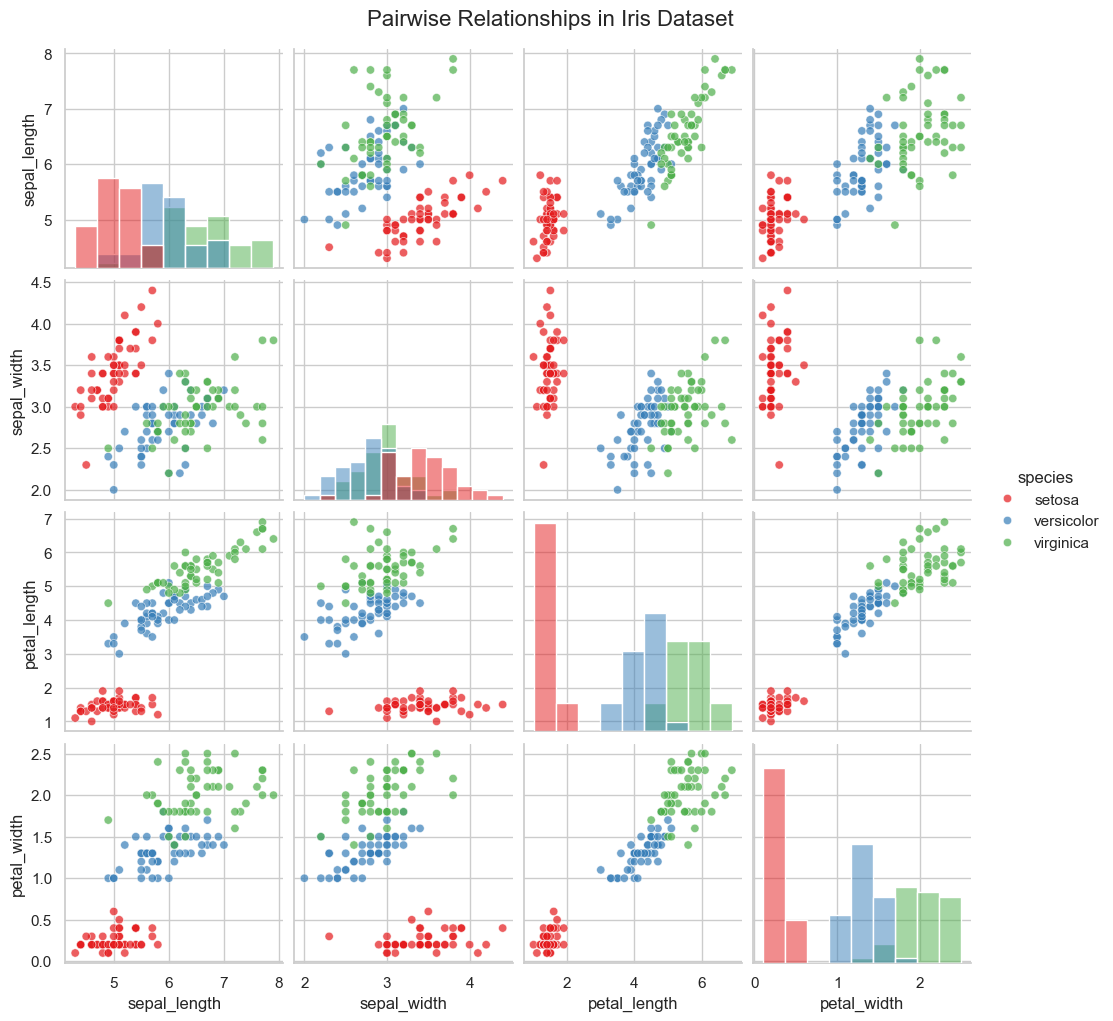

In [6]:
# 4.4 Pairplot to show relationships between all features
plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(df_iris, hue='species', diag_kind='hist',
                       palette='Set1', plot_kws={'alpha': 0.7})
pairplot.fig.suptitle('Pairwise Relationships in Iris Dataset', y=1.02, fontsize=16)
plt.show()

### 4.5 Key Statistical Summary by Species

In [7]:
# 4.5 Statistical summary by species
print("STATISTICAL SUMMARY BY SPECIES")
print("=" * 50)

for species in df_iris['species'].unique():
    print(f"\n{species.upper()} IRIS:")
    print("-" * 30)
    species_data = df_iris[df_iris['species'] == species][numeric_cols]
    print(species_data.describe().round(2))

# Calculate and display means comparison
print("\n\nMEAN COMPARISON ACROSS SPECIES:")
print("=" * 50)
means_by_species = df_iris.groupby('species')[numeric_cols].mean().round(2)
print(means_by_species)

# Identify the largest differences
print("\n\nKEY DIFFERENCES:")
print("-" * 30)
for col in numeric_cols:
    max_species = means_by_species[col].idxmax()
    min_species = means_by_species[col].idxmin()
    max_val = means_by_species[col].max()
    min_val = means_by_species[col].min()
    diff_percent = ((max_val - min_val) / min_val) * 100
    print(f"{col.replace('_', ' ').title()}:")
    print(f"  Highest: {max_species} ({max_val:.2f} cm)")
    print(f"  Lowest:  {min_species} ({min_val:.2f} cm)")
    print(f"  Difference: {diff_percent:.1f}%")
    print()

STATISTICAL SUMMARY BY SPECIES

SETOSA IRIS:
------------------------------
       sepal_length  sepal_width  petal_length  petal_width
count         50.00        50.00         50.00        50.00
mean           5.01         3.43          1.46         0.25
std            0.35         0.38          0.17         0.11
min            4.30         2.30          1.00         0.10
25%            4.80         3.20          1.40         0.20
50%            5.00         3.40          1.50         0.20
75%            5.20         3.68          1.58         0.30
max            5.80         4.40          1.90         0.60

VERSICOLOR IRIS:
------------------------------
       sepal_length  sepal_width  petal_length  petal_width
count         50.00        50.00         50.00        50.00
mean           5.94         2.77          4.26         1.33
std            0.52         0.31          0.47         0.20
min            4.90         2.00          3.00         1.00
25%            5.60         2.52   

## Section 5. Results and Conclusions

From the analysis of the iris dataset, we can observe clear differences in sepal length among the three iris species:

- **Setosa** has the shortest average sepal length
- **Versicolor** has moderate sepal length 
- **Virginica** has the longest average sepal length

The chart shows a clear progression in sepal length across species, with **Virginica** having approximately **20% longer** sepals than Setosa on average. This distinct separation in sepal measurements helps explain why the iris dataset is commonly used for classification tasks in machine learning.